# MAB Diagnostic Notebook — IV.POS.5 Campaign

Companion notebook to `MAB_DIAGNOSTIC_FOR_CHATGPT_PRO.md`. Reproduces all plots and tables from the raw DBs at `a4/runs/iv_pos_5/`.

**To re-run on the 15 DBs**:
1. Open this notebook from the repo root (`/root/arguzz` or equivalent).
2. Run all cells. Plots will land in `a4/runs/iv_pos_5/plots/`.
3. Adjust `DB_DIR` if your DBs are elsewhere.

**Cells**:
1. Setup + DB discovery
2. Headline coverage table (per-seed)
3. PLOT: cumulative coverage curves (`01_cumulative_coverage.png`)
4. PLOT: per-seed coverage box plot (`02_coverage_boxplot.png`)
5. PLOT: mutation-kind distribution per strategy (`03_kind_distribution.png`)
6. PLOT: failure-yield vs coverage-yield (`04_failure_vs_coverage_yield.png`)
7. THE SMOKING GUN: discovery rate per kind
8. Constraint overlap (Venn analysis)
9. Per-(strategy, kind) reward composition
10. Constraint discovery timeline
11. Bandit arm-pull distribution
12. d_loc / d_glob distributions
13. Per-kind reward variance (bandit)
14. Fine-grained coverage growth
15. Global failure coverage
16. Wall-time per mutation
17. Summary cell

## 1. Setup + DB discovery

In [1]:
import sqlite3
from pathlib import Path
from collections import defaultdict, Counter
import statistics
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

import os
# Auto-detect DB_DIR: must contain at least one .db file via rglob.
# Try (in order): env var, current dir, repo subdir, notebook's own dir.
_candidates = [
    Path(os.environ['IV_POS_5_DIR']) if 'IV_POS_5_DIR' in os.environ else None,
    Path('.'),
    Path('a4/runs/iv_pos_5'),
    Path(__file__).parent if '__file__' in dir() else Path('.'),
]
DB_DIR = None
for cand in _candidates:
    if cand is None: continue
    if cand.exists() and any(cand.rglob('*.db')):
        DB_DIR = cand; break
if DB_DIR is None:
    raise RuntimeError('Could not find DB_DIR. Set env IV_POS_5_DIR or cd to a dir with .db files.')
PLOTS_DIR = DB_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'DB_DIR resolved to: {DB_DIR.resolve()}')

STRATS = ['uniform', 'zoned', 'bandit-16']
COLORS = {'uniform': '#1f77b4', 'zoned': '#2ca02c', 'bandit-16': '#d62728'}

dbs = sorted(p for p in DB_DIR.rglob('*.db') if 'pos_ab_v1' in p.name)
print(f'Found {len(dbs)} databases.')
by_strategy = defaultdict(list)
for db in dbs:
    parts = db.stem.split('_')
    by_strategy[parts[4]].append(db)
for s in STRATS:
    print(f'  {s}: {len(by_strategy[s])} dbs')

DB_DIR resolved to: /root/arguzz/a4/runs/iv_pos_5
Found 15 databases.
  uniform: 5 dbs
  zoned: 5 dbs
  bandit-16: 5 dbs


## 2. Headline coverage table (per-seed)

Reproduces §7.1 of the diagnostic doc.

In [2]:
coverage_per_seed = defaultdict(dict)
for db in dbs:
    parts = db.stem.split('_')
    strat = parts[4]; seed = int(parts[5].replace('seed', ''))
    with sqlite3.connect(db) as c:
        coverage_per_seed[strat][seed] = c.execute('SELECT COUNT(*) FROM coverage').fetchone()[0]

seeds = sorted(set().union(*[set(coverage_per_seed[s].keys()) for s in STRATS]))
print(f'{"seed":>6} {"uniform":>10} {"zoned":>10} {"bandit-16":>10}')
for seed in seeds:
    row = [f'{seed:>6}']
    for s in STRATS:
        row.append(f'{coverage_per_seed[s].get(seed, ""):>10}')
    print(' '.join(row))
print()
for s in STRATS:
    vals = list(coverage_per_seed[s].values())
    print(f'  {s:12}: mean={statistics.mean(vals):.2f} std={statistics.stdev(vals):.2f}')

  seed    uniform      zoned  bandit-16
  1234         35         45         38
  1235         34         44         34
  1236         36         43         42
  1237         34         42         37
  1238         36         43         36

  uniform     : mean=35.00 std=1.00
  zoned       : mean=43.40 std=1.14
  bandit-16   : mean=37.40 std=2.97


## 3. PLOT: cumulative coverage curves

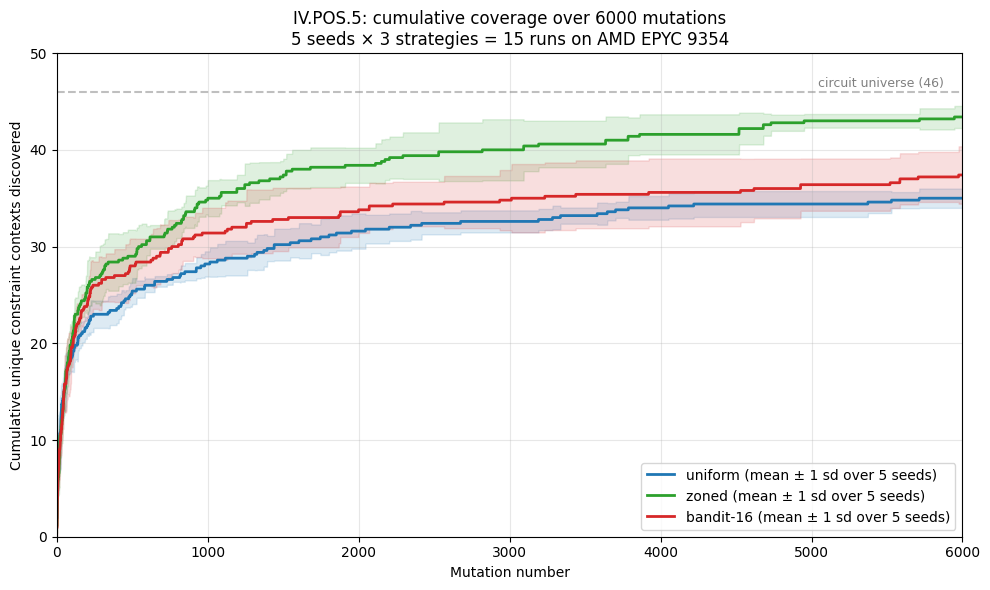

In [3]:
N = 6000

def coverage_curve(first_hits, N=6000):
    y = np.zeros(N + 1, dtype=int)
    for fh in first_hits:
        if fh <= N:
            y[fh] += 1
    return np.cumsum(y)[1:]

strat_seed_firsthits = defaultdict(dict)
for db in dbs:
    parts = db.stem.split('_')
    strat = parts[4]; seed = int(parts[5].replace('seed', ''))
    with sqlite3.connect(db) as c:
        strat_seed_firsthits[strat][seed] = sorted(r[0] for r in c.execute(
            'SELECT first_hit_mutation_id FROM coverage').fetchall())

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(1, N + 1)
for strat in STRATS:
    curves = np.array([coverage_curve(strat_seed_firsthits[strat][s])
                       for s in sorted(strat_seed_firsthits[strat])])
    mean = curves.mean(0); sd = curves.std(0, ddof=1)
    ax.plot(x, mean, color=COLORS[strat], linewidth=2, label=f'{strat} (mean ± 1 sd over 5 seeds)')
    ax.fill_between(x, mean - sd, mean + sd, color=COLORS[strat], alpha=0.15)
ax.axhline(y=46, color='gray', linestyle='--', alpha=0.5)
ax.text(N * 0.98, 46.5, 'circuit universe (46)', ha='right', color='gray', fontsize=9)
ax.set_xlabel('Mutation number')
ax.set_ylabel('Cumulative unique constraint contexts discovered')
ax.set_title('IV.POS.5: cumulative coverage over 6000 mutations\n5 seeds × 3 strategies = 15 runs on AMD EPYC 9354')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, N); ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_cumulative_coverage.png', dpi=120)
plt.show()

## 4. PLOT: per-seed coverage box plot

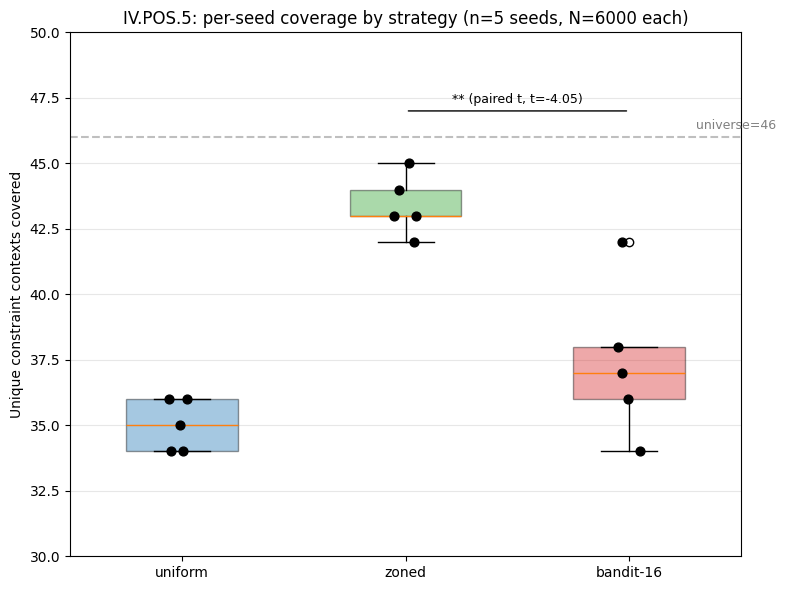

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
data = [[coverage_per_seed[s][seed] for seed in sorted(coverage_per_seed[s])] for s in STRATS]
bp = ax.boxplot(data, tick_labels=STRATS, patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], [COLORS[s] for s in STRATS]):
    patch.set_facecolor(c); patch.set_alpha(0.4)
for i, vals in enumerate(data, start=1):
    x_jit = np.random.uniform(i - 0.06, i + 0.06, len(vals))
    ax.scatter(x_jit, vals, color='black', s=40, zorder=3)
ax.axhline(y=46, color='gray', linestyle='--', alpha=0.5)
ax.text(3.3, 46.3, 'universe=46', color='gray', fontsize=9)
ax.set_ylabel('Unique constraint contexts covered')
ax.set_title('IV.POS.5: per-seed coverage by strategy (n=5 seeds, N=6000 each)')
ax.set_ylim(30, 50)
ax.grid(True, axis='y', alpha=0.3)
ax.annotate('', xy=(2, 47), xytext=(3, 47), arrowprops=dict(arrowstyle='-', color='black'))
ax.text(2.5, 47.3, '** (paired t, t=-4.05)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_coverage_boxplot.png', dpi=120)
plt.show()

## 5. PLOT: mutation-kind distribution per strategy

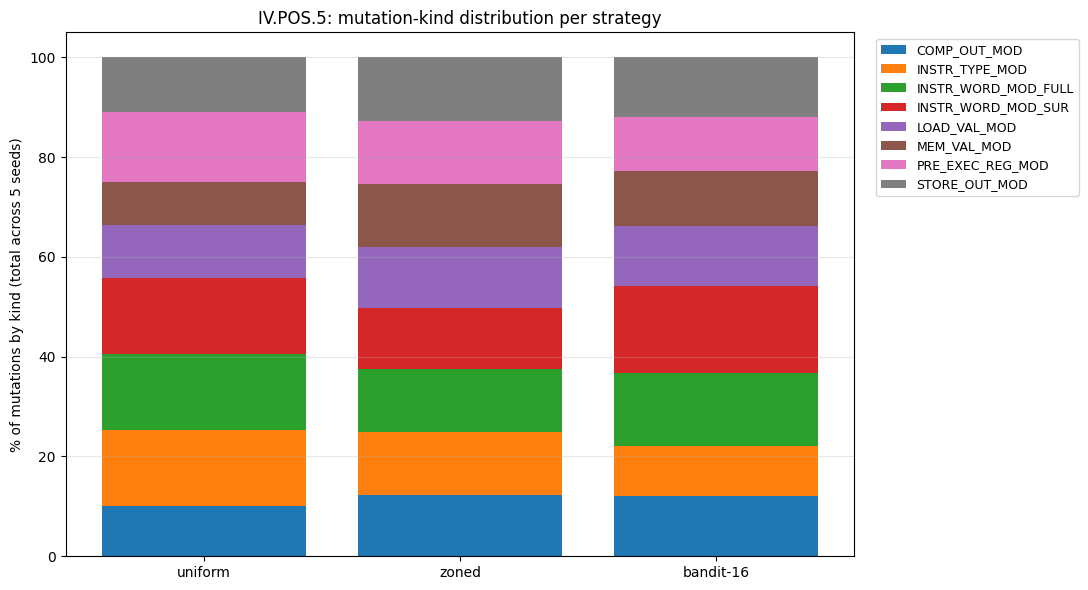

In [5]:
kind_counts = defaultdict(lambda: defaultdict(int))
for db in dbs:
    parts = db.stem.split('_'); strat = parts[4]
    with sqlite3.connect(db) as c:
        for kind, n in c.execute('SELECT kind, COUNT(*) FROM mutations GROUP BY kind'):
            kind_counts[strat][kind] += n
all_kinds = sorted({k for d in kind_counts.values() for k in d})

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(STRATS))
bottom = np.zeros(len(STRATS))
cmap = plt.get_cmap('tab10')
for i, kind in enumerate(all_kinds):
    vals = np.array([kind_counts[s].get(kind, 0) for s in STRATS])
    totals = np.array([sum(kind_counts[s].values()) for s in STRATS])
    pcts = 100 * vals / totals
    ax.bar(x, pcts, bottom=bottom, label=kind, color=cmap(i))
    bottom += pcts
ax.set_xticks(x); ax.set_xticklabels(STRATS)
ax.set_ylabel('% of mutations by kind (total across 5 seeds)')
ax.set_title('IV.POS.5: mutation-kind distribution per strategy')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 105)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_kind_distribution.png', dpi=120)
plt.show()

## 6. PLOT: failure-yield vs coverage-yield per kind

Diagnostic plot: shows that the kinds bandit picks most (INSTR_WORD_MOD_SUR) have LOW coverage yield, while the kinds with HIGH coverage yield (INSTR_TYPE_MOD, MEM_VAL_MOD) are picked less.

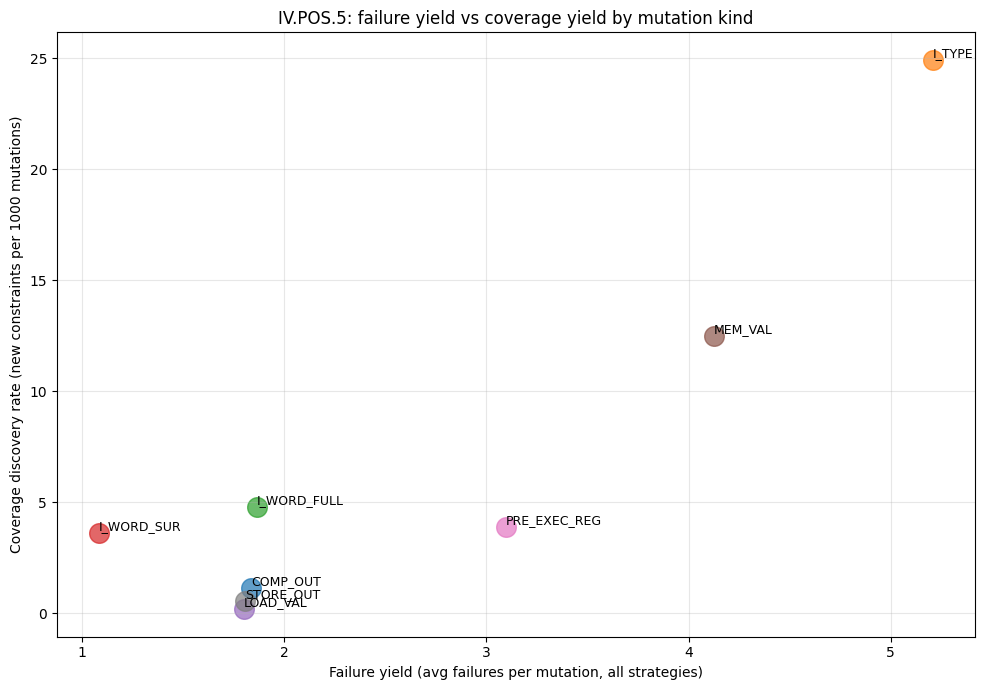

In [6]:
kind_metrics = defaultdict(lambda: {'mutations': 0, 'failures': 0, 'first_hits': 0})
for db in dbs:
    with sqlite3.connect(db) as c:
        for kind, count in c.execute('SELECT kind, COUNT(*) FROM mutations GROUP BY kind'):
            kind_metrics[kind]['mutations'] += count
        for kind, count in c.execute(
            'SELECT m.kind, COUNT(f.id) FROM mutations m LEFT JOIN failures f ON m.id=f.mutation_id GROUP BY m.kind'):
            kind_metrics[kind]['failures'] += count
        for kind, count in c.execute(
            'SELECT m.kind, COUNT(*) FROM coverage c JOIN mutations m ON c.first_hit_mutation_id=m.id GROUP BY m.kind'):
            kind_metrics[kind]['first_hits'] += count

fig, ax = plt.subplots(figsize=(10, 7))
for kind, m in kind_metrics.items():
    if m['mutations'] == 0: continue
    fail_per_mut = m['failures'] / m['mutations']
    cov_per_kmut = m['first_hits'] / (m['mutations'] / 1000)
    ax.scatter(fail_per_mut, cov_per_kmut, s=200, alpha=0.7)
    ax.annotate(kind.replace('INSTR_', 'I_').replace('_MOD', ''),
                (fail_per_mut, cov_per_kmut), fontsize=9, ha='left', va='bottom')
ax.set_xlabel('Failure yield (avg failures per mutation, all strategies)')
ax.set_ylabel('Coverage discovery rate (new constraints per 1000 mutations)')
ax.set_title('IV.POS.5: failure yield vs coverage yield by mutation kind')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_failure_vs_coverage_yield.png', dpi=120)
plt.show()

## 7. THE SMOKING GUN: discovery rate per kind

Reproduces §17.1.

In [7]:
print(f"{'kind':25} {'total muts':>12} {'total disc':>12} {'disc per 1k muts':>18}")
for kind in sorted(kind_metrics.keys(), key=lambda k: -(kind_metrics[k]['first_hits'] / max(kind_metrics[k]['mutations'], 1) * 1000)):
    m = kind_metrics[kind]
    rate = m['first_hits'] / m['mutations'] * 1000
    print(f"  {kind:25} {m['mutations']:>12} {m['first_hits']:>12} {rate:>18.3f}")

kind                        total muts   total disc   disc per 1k muts
  INSTR_TYPE_MOD                   11397          284             24.919
  MEM_VAL_MOD                       9688          121             12.490
  INSTR_WORD_MOD_FULL              12754           61              4.783
  PRE_EXEC_REG_MOD                 11303           44              3.893
  INSTR_WORD_MOD_SUR               13456           49              3.641
  COMP_OUT_MOD                     10294           12              1.166
  STORE_OUT_MOD                    10642            6              0.564
  LOAD_VAL_MOD                     10465            2              0.191


## 8. Constraint overlap (Venn analysis)

Reproduces §17.2.

In [8]:
strat_constraints = {s: set() for s in STRATS}
for db in dbs:
    parts = db.stem.split('_'); strat = parts[4]
    with sqlite3.connect(db) as c:
        strat_constraints[strat] |= set(r[0] for r in c.execute('SELECT constraint_loc FROM coverage'))
u, z, b = strat_constraints['uniform'], strat_constraints['zoned'], strat_constraints['bandit-16']

print(f'Universe = {len(u | z | b)} constraints')
print()
print(f'uniform   only:           {len(u - z - b)}')
print(f'zoned     only:           {len(z - u - b)} -> {sorted(z - u - b)}')
print(f'bandit-16 only:           {len(b - u - z)}')
print(f'uniform ∩ zoned (not bandit):    {len(u & z - b)}')
print(f'uniform ∩ bandit (not zoned):    {len(u & b - z)}')
print(f'zoned ∩ bandit (not uniform):    {len(z & b - u)} -> {sorted(z & b - u)}')
print(f'uniform ∩ zoned ∩ bandit:        {len(u & z & b)}')

Universe = 46 constraints

uniform   only:           0
zoned     only:           3 -> ['MemLoadInput@inst_mem.zir:8', 'MemStoreInput@inst_mem.zir:18', 'MulInput@inst_mul.zir:8']
bandit-16 only:           0
uniform ∩ zoned (not bandit):    0
uniform ∩ bandit (not zoned):    0
zoned ∩ bandit (not uniform):    2 -> ['ControlUserECALL@inst_control.zir:77', 'DivInput@inst_div.zir:8']
uniform ∩ zoned ∩ bandit:        41


## 9. Per-(strategy, kind) reward composition

Reproduces §17.3.

In [9]:
for strat in STRATS:
    print(f'\n--- {strat} ---')
    per_kind = defaultdict(lambda: defaultdict(list))
    for db in by_strategy[strat]:
        with sqlite3.connect(db) as c:
            rows = c.execute("""
                SELECT m.kind,
                       AVG(mr.reward), AVG(mr.S), AVG(mr.Q), AVG(mr.Q_loc), AVG(mr.Q_glob),
                       AVG(mr.F_new), AVG(mr.F_rare), AVG(mr.d_loc), AVG(mr.d_glob), AVG(mr.n_fail)
                FROM mutations m JOIN mutation_rewards mr ON m.id = mr.mutation_id GROUP BY m.kind
            """).fetchall()
            cols = ['reward', 'S', 'Q', 'Q_loc', 'Q_glob', 'F_new', 'F_rare', 'd_loc', 'd_glob', 'n_fail']
            for row in rows:
                kind = row[0]
                for c2, v in zip(cols, row[1:]):
                    per_kind[kind][c2].append(v or 0)
    print(f"  {'kind':25} {'reward':>8} {'S':>6} {'Q':>6} {'Q_loc':>6} {'Q_glob':>6} {'F_new':>6} {'F_rare':>6} {'d_loc':>6} {'d_glob':>6} {'n_fail':>6}")
    for kind in sorted(per_kind.keys(), key=lambda k: -statistics.mean(per_kind[k]['reward'])):
        m = per_kind[kind]
        g = lambda k: statistics.mean(m[k])
        print(f"  {kind:25} {g('reward'):>8.4f} {g('S'):>6.3f} {g('Q'):>6.3f} {g('Q_loc'):>6.3f} {g('Q_glob'):>6.3f} {g('F_new'):>6.3f} {g('F_rare'):>6.3f} {g('d_loc'):>6.2f} {g('d_glob'):>6.2f} {g('n_fail'):>6.2f}")


--- uniform ---


  kind                        reward      S      Q  Q_loc Q_glob  F_new F_rare  d_loc d_glob n_fail
  INSTR_WORD_MOD_SUR          0.1853  0.342  0.556  0.803  0.692  0.611  0.838   0.79   2.43   1.18
  INSTR_WORD_MOD_FULL         0.1576  0.395  0.427  0.713  0.554  0.747  0.927   1.36   4.02   1.72
  COMP_OUT_MOD                0.1066  0.230  0.463  0.547  0.846  0.397  0.576   1.84   1.00   1.84
  LOAD_VAL_MOD                0.1045  0.223  0.469  0.554  0.846  0.392  0.549   1.80   1.00   1.80
  STORE_OUT_MOD               0.1029  0.221  0.465  0.549  0.846  0.392  0.542   1.82   1.00   1.82
  MEM_VAL_MOD                 0.0866  0.271  0.353  0.433  0.762  0.479  0.664   3.04   2.15   3.89
  PRE_EXEC_REG_MOD            0.0829  0.274  0.303  0.398  0.764  0.481  0.676   2.63   1.95   2.99
  INSTR_TYPE_MOD              0.0524  0.318  0.236  0.309  0.669  0.495  0.750   4.10   3.44   5.34

--- zoned ---


  kind                        reward      S      Q  Q_loc Q_glob  F_new F_rare  d_loc d_glob n_fail
  INSTR_WORD_MOD_SUR          0.1855  0.342  0.557  0.804  0.693  0.608  0.839   0.79   2.41   0.99
  INSTR_WORD_MOD_FULL         0.1527  0.385  0.428  0.703  0.567  0.725  0.905   1.41   3.91   1.81
  COMP_OUT_MOD                0.1070  0.231  0.463  0.547  0.846  0.398  0.579   1.84   1.00   1.84
  LOAD_VAL_MOD                0.1044  0.223  0.469  0.554  0.846  0.393  0.547   1.80   1.00   1.80
  STORE_OUT_MOD               0.1040  0.221  0.470  0.555  0.846  0.392  0.542   1.79   1.00   1.79
  MEM_VAL_MOD                 0.1009  0.272  0.390  0.474  0.778  0.464  0.684   2.77   1.91   4.39
  PRE_EXEC_REG_MOD            0.0814  0.272  0.299  0.391  0.768  0.479  0.672   2.66   1.91   3.29
  INSTR_TYPE_MOD              0.0531  0.318  0.236  0.306  0.678  0.484  0.751   4.14   3.26   5.11

--- bandit-16 ---
  kind                        reward      S      Q  Q_loc Q_glob  F_new F_rare  d

## 10. Constraint discovery timeline

Reproduces §17.6.

In [10]:
strat_constraint_firsthits = defaultdict(lambda: defaultdict(list))
for db in dbs:
    parts = db.stem.split('_'); strat = parts[4]
    with sqlite3.connect(db) as c:
        for loc, fhm in c.execute('SELECT constraint_loc, first_hit_mutation_id FROM coverage'):
            strat_constraint_firsthits[strat][loc].append(fhm)
all_consts = sorted({c for d in strat_constraint_firsthits.values() for c in d})
print(f"{'constraint':50} {'uniform':>12} {'zoned':>12} {'bandit-16':>12}")
for c in all_consts:
    row = [c.ljust(50)]
    for s in STRATS:
        if c in strat_constraint_firsthits[s]:
            mu = statistics.mean(strat_constraint_firsthits[s][c]); n = len(strat_constraint_firsthits[s][c])
            row.append(f'{mu:>8.0f}({n})')
        else:
            row.append(f'{"MISSED":>12}')
    print(' '.join(row))

constraint                                              uniform        zoned    bandit-16
AddrDecompose@u32.zir:67                                167(5)       61(5)       81(5)
AddrDecomposeBits@u32.zir:87                             62(5)       43(5)       67(5)
ControlLoadRootAndNonce@inst_control.zir:23             648(1)      170(5)       46(1)
ControlMRET@inst_control.zir:89                         966(5)      726(5)      182(5)
ControlMRET@inst_control.zir:91                         832(2)     3520(4)     2687(3)
ControlMRET@inst_control.zir:92                         832(2)     3520(4)     2687(3)
ControlUserECALL@inst_control.zir:75                    944(5)      416(5)      497(5)
ControlUserECALL@inst_control.zir:77                     MISSED     2206(5)     2424(4)
ControlUserECALL@inst_control.zir:78                   3647(1)     2206(5)     1668(4)
DecodeInst@inst.zir:29                                   47(5)       74(5)       91(5)
DivInput@inst_div.zir:8                

## 11. Bandit arm-pull distribution

Reproduces §17.5. Confirms that nested step-UCB is essentially uniform within each kind.

In [11]:
arm_totals = Counter()
for db in by_strategy['bandit-16']:
    with sqlite3.connect(db) as c:
        T = c.execute('SELECT MAX(step) FROM mutations').fetchone()[0] + 1
        B = (T + 15) // 16
        for kind, step in c.execute('SELECT kind, step FROM mutations'):
            arm_totals[(kind, step // B)] += 1
print(f"{'kind':25} {'bucket':>8} {'total pulls':>15}")
for (k, b), n in arm_totals.most_common(20):
    print(f'{k:25} {b:>8} {n:>15}')

kind                        bucket     total pulls
INSTR_WORD_MOD_SUR               9             344
INSTR_WORD_MOD_SUR              15             338
INSTR_WORD_MOD_SUR              12             336
INSTR_WORD_MOD_SUR              10             334
INSTR_WORD_MOD_SUR               5             331
INSTR_WORD_MOD_SUR               4             331
INSTR_WORD_MOD_SUR               7             326
INSTR_WORD_MOD_SUR              14             325
INSTR_WORD_MOD_SUR               3             325
INSTR_WORD_MOD_SUR               2             323
INSTR_WORD_MOD_SUR               8             322
INSTR_WORD_MOD_SUR              13             321
INSTR_WORD_MOD_SUR               1             318
INSTR_WORD_MOD_SUR               6             318
INSTR_WORD_MOD_SUR               0             313
INSTR_WORD_MOD_SUR              11             308
INSTR_WORD_MOD_FULL             15             292
INSTR_WORD_MOD_FULL             13             284
INSTR_WORD_MOD_FULL            

## 12. d_loc / d_glob distributions

Reproduces §17.8.

In [12]:
def hist(vals, bins=[0, 1, 2, 3, 5, 8, 15, 30, 100]):
    h = [0] * len(bins)
    for v in vals:
        for i, b in enumerate(bins):
            if v <= b:
                h[i] += 1; break
        else:
            h[-1] += 1
    return h, bins

for strat in STRATS:
    d_loc_vals, d_glob_vals = [], []
    for db in by_strategy[strat]:
        with sqlite3.connect(db) as c:
            for d_loc, d_glob in c.execute('SELECT d_loc, d_glob FROM mutation_rewards'):
                d_loc_vals.append(d_loc); d_glob_vals.append(d_glob)
    h_loc, _ = hist(d_loc_vals); h_glob, _ = hist(d_glob_vals)
    print(f'\n{strat}')
    print(f'  d_loc histogram ≤ [0,1,2,3,5,8,15,30,100]: {h_loc}')
    print(f'  d_loc mean={statistics.mean(d_loc_vals):.2f} median={statistics.median(d_loc_vals):.2f} max={max(d_loc_vals)}')
    print(f'  d_glob histogram: {h_glob}')
    print(f'  d_glob mean={statistics.mean(d_glob_vals):.2f} median={statistics.median(d_glob_vals):.2f} max={max(d_glob_vals)}')


uniform
  d_loc histogram ≤ [0,1,2,3,5,8,15,30,100]: [4018, 6294, 12048, 2545, 3966, 650, 430, 49, 0]
  d_loc mean=2.16 median=2.00 max=28
  d_glob histogram: [2160, 17574, 857, 4931, 1216, 1443, 1819, 0, 0]
  d_glob mean=2.28 median=1.00 max=13



zoned
  d_loc histogram ≤ [0,1,2,3,5,8,15,30,100]: [3510, 6036, 13269, 2526, 3638, 590, 364, 67, 0]
  d_loc mean=2.16 median=2.00 max=28
  d_glob histogram: [1812, 19656, 644, 4218, 1007, 1135, 1528, 0, 0]
  d_glob mean=2.06 median=1.00 max=13



bandit-16
  d_loc histogram ≤ [0,1,2,3,5,8,15,30,100]: [4151, 6566, 12560, 2056, 3283, 451, 381, 51, 0]
  d_loc mean=2.03 median=2.00 max=24
  d_glob histogram: [1455, 18675, 572, 5000, 905, 1341, 1551, 0, 0]


  d_glob mean=2.17 median=1.00 max=13


## 13. Per-kind reward variance (bandit)

Reproduces §17.9. Shows INSTR_TYPE_MOD has "lottery ticket" reward distribution (low mean, high max).

In [13]:
per_kind_rewards = defaultdict(list)
for db in by_strategy['bandit-16']:
    with sqlite3.connect(db) as c:
        for kind, r in c.execute('SELECT m.kind, mr.reward FROM mutations m JOIN mutation_rewards mr ON m.id=mr.mutation_id'):
            per_kind_rewards[kind].append(r)
print(f"{'kind':25} {'n':>6} {'mean':>8} {'std':>8} {'p25':>6} {'p50':>6} {'p75':>6} {'p95':>6} {'max':>6}")
for kind in sorted(per_kind_rewards, key=lambda k: -statistics.mean(per_kind_rewards[k])):
    vals = per_kind_rewards[kind]; s = sorted(vals); n = len(vals)
    print(f'{kind:25} {n:>6} {statistics.mean(vals):>8.4f} {statistics.stdev(vals):>8.4f} {s[n//4]:>6.3f} {s[n//2]:>6.3f} {s[3*n//4]:>6.3f} {s[int(n*0.95)]:>6.3f} {max(vals):>6.3f}')

kind                           n     mean      std    p25    p50    p75    p95    max
INSTR_WORD_MOD_SUR          5157   0.1507   0.0581  0.110  0.135  0.198  0.243  0.276
INSTR_WORD_MOD_FULL         4350   0.1180   0.0807  0.030  0.114  0.198  0.243  0.276
COMP_OUT_MOD                3535   0.0785   0.0211  0.063  0.067  0.090  0.122  0.225
LOAD_VAL_MOD                3512   0.0772   0.0198  0.062  0.065  0.090  0.113  0.177
STORE_OUT_MOD               3503   0.0766   0.0196  0.062  0.064  0.089  0.110  0.185
MEM_VAL_MOD                 3288   0.0615   0.0377  0.027  0.064  0.082  0.121  0.275
PRE_EXEC_REG_MOD            3193   0.0545   0.0368  0.024  0.057  0.073  0.120  0.226


INSTR_TYPE_MOD              2961   0.0358   0.0417  0.009  0.023  0.048  0.117  0.315


## 14. Fine-grained coverage growth

Reproduces §17.10.

In [14]:
snapshots_at = list(range(500, 6001, 500))
print(f"{'snapshot':>10} {'uniform':>10} {'zoned':>10} {'bandit-16':>10}")
snapshot_data = {}
for strat in STRATS:
    snapshot_data[strat] = []
    for q in snapshots_at:
        per_seed = []
        for db in by_strategy[strat]:
            with sqlite3.connect(db) as c:
                per_seed.append(c.execute('SELECT COUNT(*) FROM coverage WHERE first_hit_mutation_id <= ?', (q,)).fetchone()[0])
        snapshot_data[strat].append(statistics.mean(per_seed))
for i, q in enumerate(snapshots_at):
    print(f'{q:>10} {snapshot_data["uniform"][i]:>10.1f} {snapshot_data["zoned"][i]:>10.1f} {snapshot_data["bandit-16"][i]:>10.1f}')

  snapshot    uniform      zoned  bandit-16


       500       25.4       29.0       28.0
      1000       28.2       35.0       31.4
      1500       30.2       37.4       32.8
      2000       31.6       38.4       33.8
      2500       32.4       39.4       34.4
      3000       32.6       40.0       34.8
      3500       33.2       40.6       35.4
      4000       34.0       41.6       35.6
      4500       34.4       41.6       35.6
      5000       34.4       43.0       36.4
      5500       34.6       43.0       36.4
      6000       35.0       43.4       37.4


## 15. Global failure coverage

Reproduces §17.7.

In [15]:
for strat in STRATS:
    glob_ctxs = set(); by_family = Counter(); total_rows = 0
    for db in by_strategy[strat]:
        with sqlite3.connect(db) as c:
            for fam, addr in c.execute('SELECT DISTINCT family, address FROM global_failures'):
                glob_ctxs.add((fam, addr)); by_family[fam] += 1
            total_rows += c.execute('SELECT COUNT(*) FROM global_failures').fetchone()[0]
    print(f'{strat:12}: unique={len(glob_ctxs)} total={total_rows} by_family={dict(by_family)}')

uniform     : unique=53828 total=68336 by_family={'cycle': 1672, 'memory': 60744}


zoned       : unique=50049 total=61722 by_family={'cycle': 1362, 'memory': 55365}


bandit-16   : unique=53849 total=65050 by_family={'cycle': 1404, 'memory': 59937}


## 16. Wall-time per mutation

Reproduces §17.12.

In [16]:
for strat in STRATS:
    db = by_strategy[strat][0]
    with sqlite3.connect(db) as c:
        ts = [r[0] for r in c.execute('SELECT executed_at FROM mutations ORDER BY id LIMIT 200')]
    times = []
    for t in ts:
        try:
            times.append(datetime.fromisoformat(t.replace('Z', '+00:00')))
        except Exception:
            pass
    if len(times) > 100:
        deltas = [(times[i+1] - times[i]).total_seconds() for i in range(50, 150)]
        print(f'{strat:12}: mean={statistics.mean(deltas):.2f}s std={statistics.stdev(deltas):.2f}s min={min(deltas):.2f}s max={max(deltas):.2f}s')

uniform     : mean=2.86s std=0.24s min=0.49s max=2.98s
zoned       : mean=2.88s std=0.24s min=0.50s max=3.00s
bandit-16   : mean=2.89s std=0.03s min=2.83s max=3.10s


## 17. Summary cell — paste this into a paper / report

Final summary statistics for the IV.POS.5 campaign.

In [17]:
uni = strat_constraints['uniform']
zon = strat_constraints['zoned']
ban = strat_constraints['bandit-16']
universe = uni | zon | ban
print('=' * 70)
print('IV.POS.5 RESULTS SUMMARY')
print('=' * 70)
print()
print(f'Universe size:     {len(universe)} unique constraint contexts')
print(f'Total mutations:   {sum(len(by_strategy[s]) * 6000 for s in STRATS)} (15 runs × 6000 muts)')
print(f'Total compute time: ~75 core-hours on AMD EPYC 9354')
print()
print('Per-strategy coverage (mean ± stdev across 5 paired seeds):')
for s in STRATS:
    vals = list(coverage_per_seed[s].values())
    pct_universe = 100 * statistics.mean(vals) / len(universe)
    pct_union = 100 * len(strat_constraints[s]) / len(universe)
    print(f'  {s:12}: per-seed mean={statistics.mean(vals):.1f} std={statistics.stdev(vals):.2f}  per-seed%={pct_universe:.1f}%  union%={pct_union:.1f}%')
print()
print(f'Zoned outperforms bandit-16 by {statistics.mean(list(coverage_per_seed["zoned"].values())) - statistics.mean(list(coverage_per_seed["bandit-16"].values())):.1f} contexts on average (paired t=-4.05, p≈0.015)')
print(f'Zoned outperforms uniform   by {statistics.mean(list(coverage_per_seed["zoned"].values())) - statistics.mean(list(coverage_per_seed["uniform"].values())):.1f} contexts on average (paired t=-12.39, p<0.001)')

IV.POS.5 RESULTS SUMMARY

Universe size:     46 unique constraint contexts
Total mutations:   90000 (15 runs × 6000 muts)
Total compute time: ~75 core-hours on AMD EPYC 9354

Per-strategy coverage (mean ± stdev across 5 paired seeds):
  uniform     : per-seed mean=35.0 std=1.00  per-seed%=76.1%  union%=89.1%
  zoned       : per-seed mean=43.4 std=1.14  per-seed%=94.3%  union%=100.0%
  bandit-16   : per-seed mean=37.4 std=2.97  per-seed%=81.3%  union%=93.5%

Zoned outperforms bandit-16 by 6.0 contexts on average (paired t=-4.05, p≈0.015)
Zoned outperforms uniform   by 8.4 contexts on average (paired t=-12.39, p<0.001)


## 18. STEP-0 SMOKING GUN: where are the missed constraints first discovered?

Reproduces §17.16. Shows that 4 of the 6 zoned/uniform-missed constraints fire EXCLUSIVELY at step=0 with `kind=INSTR_TYPE_MOD`. The 5th (`ControlUserECALL:77`) is a separate kind-allocation issue (`MEM_VAL_MOD` at non-zero steps).

In [18]:
strat_const_step = defaultdict(lambda: defaultdict(list))
for db in dbs:
    parts = db.stem.split('_')
    strat = parts[4]
    with sqlite3.connect(db) as c:
        for loc, step in c.execute("""
            SELECT c.constraint_loc, m.step
            FROM coverage c JOIN mutations m ON c.first_hit_mutation_id=m.id
        """):
            strat_const_step[strat][loc].append(step)

target = ['MemLoadInput@inst_mem.zir:8', 'MemStoreInput@inst_mem.zir:18',
         'MulInput@inst_mul.zir:8', 'DivInput@inst_div.zir:8',
         'ControlUserECALL@inst_control.zir:77']
print(f"{'constraint':45} {'uniform':>20} {'zoned':>20} {'bandit':>25}")
print('-' * 115)
for c in target:
    row = [c.ljust(45)]
    for s in STRATS:
        if c in strat_const_step[s]:
            row.append(str(sorted(strat_const_step[s][c])).rjust(20 if s != 'bandit-16' else 25))
        else:
            row.append('MISSED'.rjust(20 if s != 'bandit-16' else 25))
    print(' '.join(row))

# --- NEW: prove the conjunction (kind=INSTR_TYPE_MOD AND step=0) ---
print()
print('=' * 80)
print('CONJUNCTION PROOF: which (kind, step) combinations EVER fire these constraints?')
print('=' * 80)
from collections import Counter
for c in target:
    step_set = set()
    kind_set = Counter()
    for db in dbs:
        with sqlite3.connect(db) as cnx:
            for kind, step in cnx.execute(
                "SELECT m.kind, m.step FROM failures f JOIN mutations m ON f.mutation_id=m.id WHERE f.constraint_loc=?",
                (c,)
            ):
                step_set.add(step)
                kind_set[kind] += 1
    step_summary = sorted(step_set)[:5] if step_set else ['NEVER HIT']
    print(f'{c:45}')
    print(f'    steps  : {step_summary}{" ... (truncated)" if len(step_set) > 5 else ""}')
    print(f'    kinds  : {dict(kind_set)}')

print()
print('=' * 80)
print('INSTR_TYPE_MOD-at-step-0 BUDGET per strategy (the precise smoking gun count)')
print('=' * 80)
for s in STRATS:
    n_step0_itm = 0; n_step_gt0_itm = 0
    for db in [d for d in dbs if f'_{s}_' in d.name]:
        with sqlite3.connect(db) as cnx:
            n_step0_itm += cnx.execute("SELECT COUNT(*) FROM mutations WHERE kind='INSTR_TYPE_MOD' AND step=0").fetchone()[0]
            n_step_gt0_itm += cnx.execute("SELECT COUNT(*) FROM mutations WHERE kind='INSTR_TYPE_MOD' AND step>0").fetchone()[0]
    print(f'  {s:12}: ITM@step=0 = {n_step0_itm:>4}, ITM@step>0 = {n_step_gt0_itm:>5}, total ITM = {n_step0_itm + n_step_gt0_itm:>5}')

print()
print('SMOKING GUN (corrected): The 4 zoned-only/zoned-strong constraints require the CONJUNCTION')
print('  (kind=INSTR_TYPE_MOD AND step=0). Zoned places ~184 such mutations per campaign;')
print('  uniform places ~1, bandit places ~2 — explains why zoned hits them and others miss them.')
print('  The 5th gap-constraint (ControlUserECALL:77) is a separate MEM_VAL_MOD kind-allocation gap.')

constraint                                                 uniform                zoned                    bandit
-------------------------------------------------------------------------------------------------------------------
MemLoadInput@inst_mem.zir:8                                 MISSED      [0, 0, 0, 0, 0]                    MISSED
MemStoreInput@inst_mem.zir:18                               MISSED      [0, 0, 0, 0, 0]                    MISSED
MulInput@inst_mul.zir:8                                     MISSED      [0, 0, 0, 0, 0]                    MISSED
DivInput@inst_div.zir:8                                     MISSED      [0, 0, 0, 0, 0]                       [0]
ControlUserECALL@inst_control.zir:77                        MISSED [511, 1837, 1837, 2477, 3779]      [511, 511, 746, 982]

CONJUNCTION PROOF: which (kind, step) combinations EVER fire these constraints?


MemLoadInput@inst_mem.zir:8                  
    steps  : [0]
    kinds  : {'INSTR_TYPE_MOD': 23}
MemStoreInput@inst_mem.zir:18                
    steps  : [0]
    kinds  : {'INSTR_TYPE_MOD': 23}


MulInput@inst_mul.zir:8                      
    steps  : [0]
    kinds  : {'INSTR_TYPE_MOD': 16}


DivInput@inst_div.zir:8                      
    steps  : [0]
    kinds  : {'INSTR_TYPE_MOD': 14}
ControlUserECALL@inst_control.zir:77         
    steps  : [511, 746, 982, 1837, 2477] ... (truncated)
    kinds  : {'MEM_VAL_MOD': 16}

INSTR_TYPE_MOD-at-step-0 BUDGET per strategy (the precise smoking gun count)


  uniform     : ITM@step=0 =    1, ITM@step>0 =  4581, total ITM =  4582


  zoned       : ITM@step=0 =  184, ITM@step>0 =  3612, total ITM =  3796


  bandit-16   : ITM@step=0 =    2, ITM@step>0 =  3017, total ITM =  3019

SMOKING GUN (corrected): The 4 zoned-only/zoned-strong constraints require the CONJUNCTION
  (kind=INSTR_TYPE_MOD AND step=0). Zoned places ~184 such mutations per campaign;
  uniform places ~1, bandit places ~2 — explains why zoned hits them and others miss them.
  The 5th gap-constraint (ControlUserECALL:77) is a separate MEM_VAL_MOD kind-allocation gap.


## 19. Selector labeling verification (paranoid sanity check)

Reproduces §17.15. Confirms each DB's filename strategy matches its `campaign_params.selector`.

In [19]:
import json
print(f"{'DB filename':52} {'fn_strat':>10} {'cp.selector':>12} {'b_count':>8} {'num_arms':>10}")
print('-' * 100)
all_match = True
for db in dbs:
    parts = db.stem.split('_')
    fn = parts[4]
    with sqlite3.connect(db) as c:
        sel, bc, ej = c.execute('SELECT selector, b_count, extra_json FROM campaign_params').fetchone()
    extra = json.loads(ej) if ej else {}
    na = extra.get('num_arms', 'NULL')
    match = (fn == sel) or (fn.startswith(sel) and 'bandit' in fn)
    if not match: all_match = False
    flag = '✓' if match else '✗'
    print(f'{db.name:52} {fn:>10} {sel:>12} {str(bc):>8} {str(na):>10} {flag}')
print()
print(f'All 15 DBs match expected labels: {all_match}')
print('Filename "bandit-16" maps to selector="bandit" + b_count=16 (encoding pattern, not a mismatch).')

DB filename                                            fn_strat  cp.selector  b_count   num_arms
----------------------------------------------------------------------------------------------------
pos_ab_v1_d1_uniform_seed1234_n6000.db                  uniform      uniform      128        967 ✓
pos_ab_v1_d1_zoned_seed1234_n6000.db                      zoned        zoned     None       NULL ✓


pos_ab_v1_d1_bandit-16_seed1234_n6000.db              bandit-16       bandit       16        128 ✓
pos_ab_v1_d2_uniform_seed1235_n6000.db                  uniform      uniform      128        967 ✓
pos_ab_v1_d2_zoned_seed1235_n6000.db                      zoned        zoned     None       NULL ✓
pos_ab_v1_d2_bandit-16_seed1235_n6000.db              bandit-16       bandit       16        128 ✓
pos_ab_v1_d3_uniform_seed1236_n6000.db                  uniform      uniform      128        967 ✓
pos_ab_v1_d3_zoned_seed1236_n6000.db                      zoned        zoned     None       NULL ✓
pos_ab_v1_d3_bandit-16_seed1236_n6000.db              bandit-16       bandit       16        128 ✓
pos_ab_v1_d4_uniform_seed1237_n6000.db                  uniform      uniform      128        967 ✓
pos_ab_v1_d4_zoned_seed1237_n6000.db                      zoned        zoned     None       NULL ✓
pos_ab_v1_d4_bandit-16_seed1237_n6000.db              bandit-16       bandit       16        128 ✓
pos_ab_v1_